<a href="https://colab.research.google.com/github/PreethiR091/ML-Lab/blob/main/Preethi_R_24BAD091_ML_Ex_no_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

EXPT NO: 7 - Clustering using K-Means and Gaussian Mixture Models (GMM)

SCENARIO 1 – CLUSTERING USING K-MEANS

Problem Statement

    Group customers/data points into clusters based on similarity using K-Means clustering.

Dataset (Kaggle – Public)

    Mall Customer Segmentation Dataset

Dataset Link: https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python
(You can use any dataset with numerical features)

Target Variable: Cluster labels (no predefined labels – unsupervised learning)

Input Feature:
    • Annual Income
    • Spending Score
    • Age (optional)

IN-LAB TASKS

    1.	Import required Python libraries (NumPy, Pandas, Matplotlib, Scikit-learn)
    2.	Load the dataset
    3.	Perform data preprocessing (handling missing values, scaling)
    4.	Select relevant features
    5.	Use Elbow Method to determine optimal K
    6.	Apply K-Means clustering
    7.	Assign cluster labels
    8.	Visualize clusters
    9.	Interpret cluster characteristics

Evaluation Metrics

    • Inertia (Within-cluster sum of squares)
    • Silhouette Score

Analysis Tasks

    • Observe how different K values affect clustering
    • Analyze compactness and separation of clusters
    • Identify customer segments (e.g., high income–high spending)
    • Study sensitivity to initialization

Visualization

    • Elbow curve (K vs inertia)
    • Scatter plot of clusters
    • Cluster centroids


Preethi R 24BAD091 

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64
Inertia: 65.56840815571681
Silhouette Score: 0.5546571631111091


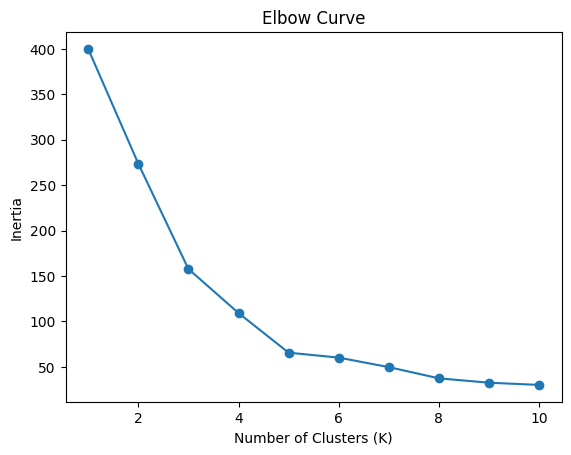

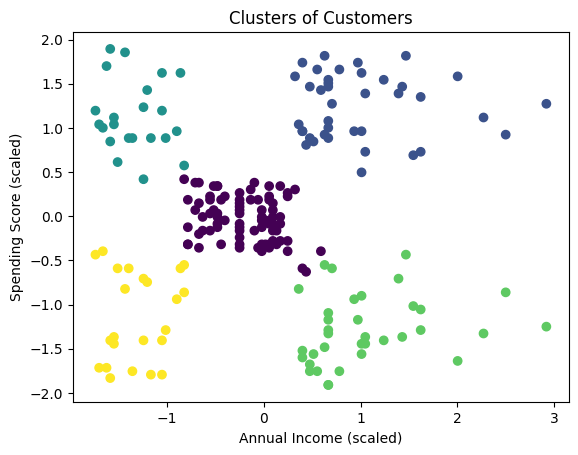

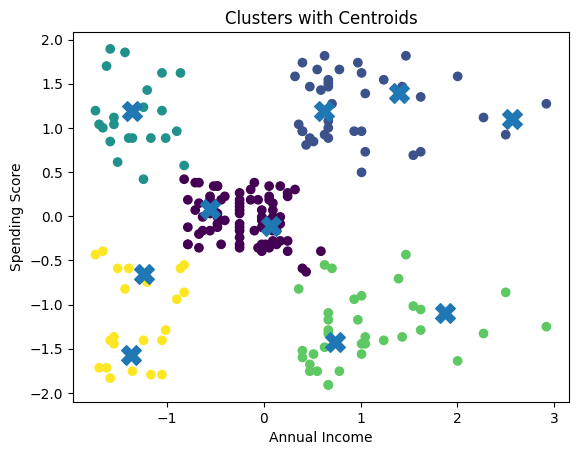

In [2]:
print("Preethi R 24BAD091 \n")
# Step 1: Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Step 2: Load Dataset
df = pd.read_csv('Mall_Customers.csv')

# Display first few rows
print(df.head())

# Step 3: Data Preprocessing
# Check missing values
print(df.isnull().sum())

# Select features
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 4: Elbow Method to find optimal K
inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Step 5: Apply K-Means (choose optimal K, e.g., 5)
kmeans = KMeans(n_clusters=5, random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)

# Step 6: Assign cluster labels
df['Cluster'] = y_kmeans

# Step 7: Evaluate Model
print("Inertia:", kmeans.inertia_)
print("Silhouette Score:", silhouette_score(X_scaled, y_kmeans))

# Step 8: Visualization
# Elbow curve (K vs inertia)
inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Curve')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.show()

# Scatter plot of clusters
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_kmeans)
plt.title('Clusters of Customers')
plt.xlabel('Annual Income (scaled)')
plt.ylabel('Spending Score (scaled)')
plt.show()

# Cluster centroids
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_kmeans)
plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 1],
            s=200, marker='X')
plt.title('Clusters with Centroids')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.show()


SCENARIO 2 – CLUSTERING USING GMM

Problem Statement

    Cluster data using Gaussian Mixture Models to capture probabilistic cluster membership.

Dataset (Same / Alternative Dataset)

    Same dataset (or any numerical dataset)

Target Variable: Cluster probabilities and labels

Input Features

    • Annual Income
    • Spending Score
    • Age (optional)

IN-LAB TASKS

    1.	Load dataset
    2.	Perform preprocessing and scaling
    3.	Apply Gaussian Mixture Model (GMM)
    4.	Choose number of components (clusters)
    5.	Fit model using Expectation-Maximization (EM)
    6.	Predict cluster probabilities
    7.	Assign clusters based on highest probability
    8.	Compare with K-Means clustering

Evaluation Metrics

    • Log-Likelihood
    • AIC (Akaike Information Criterion)
    • BIC (Bayesian Information Criterion)
    • Silhouette Score

Analysis Tasks

    • Compare soft vs hard clustering
    • Analyze overlapping clusters
    • Observe cluster shapes (elliptical vs spherical)
    • Compare flexibility with K-Means

Visualization

    • Cluster probability distribution
    • GMM contour plots
    • Comparison plot (K-Means vs GMM)



Preethi R 24BAD091 

Log-Likelihood: -2.262502621973241
AIC: 963.0010487892964
BIC: 1058.6522524191894
Silhouette Score: 0.5536892843811245


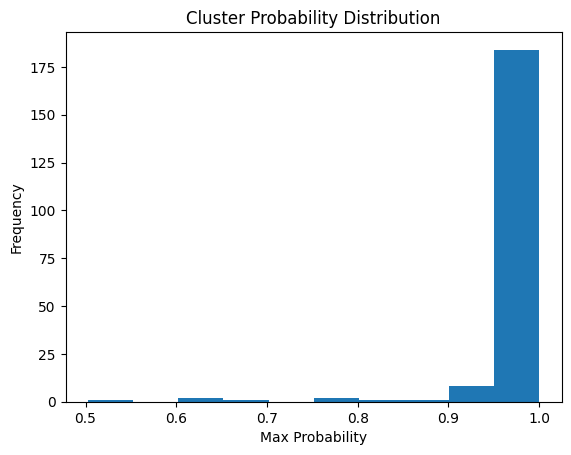

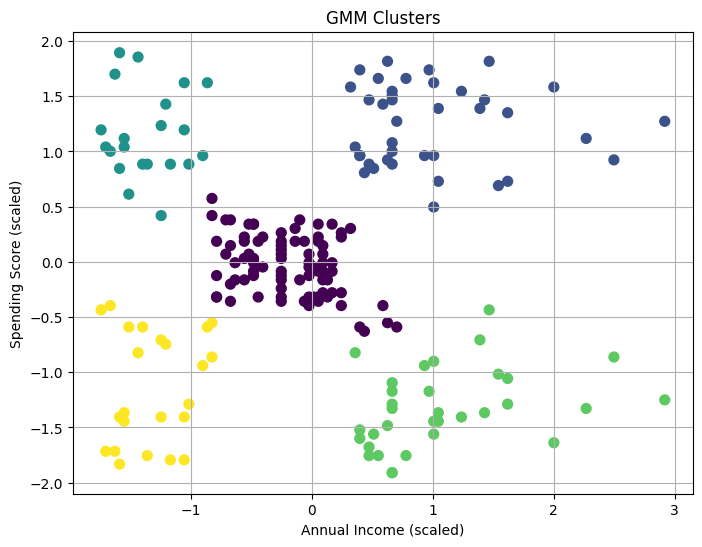

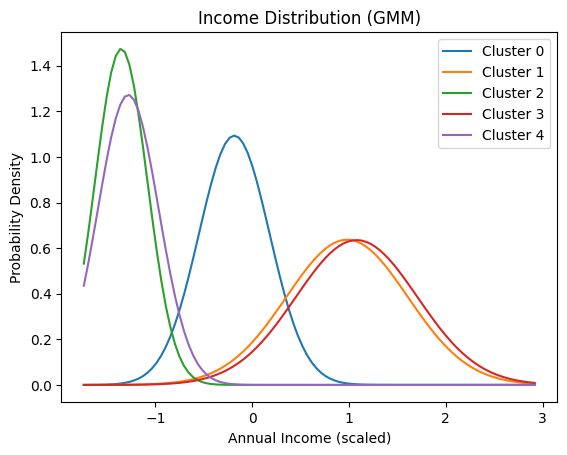

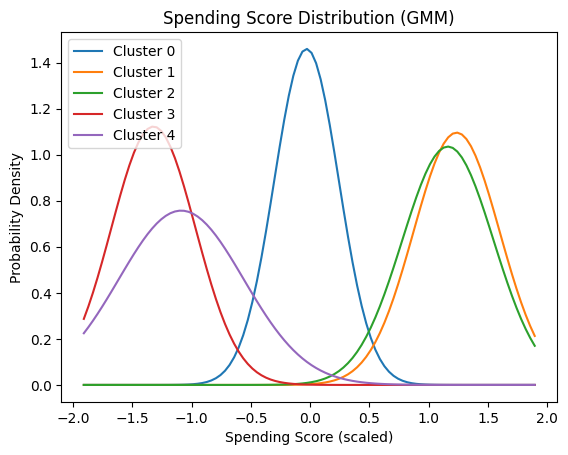

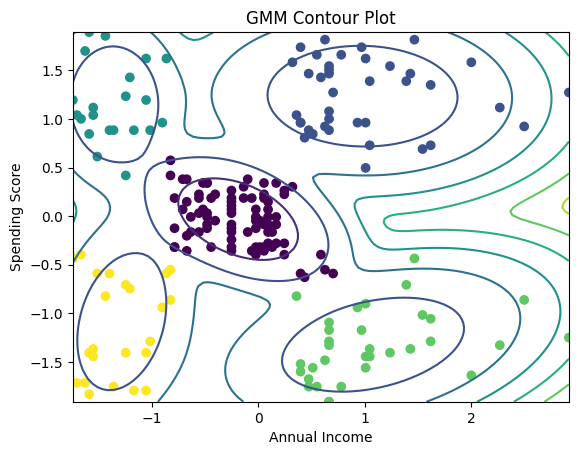

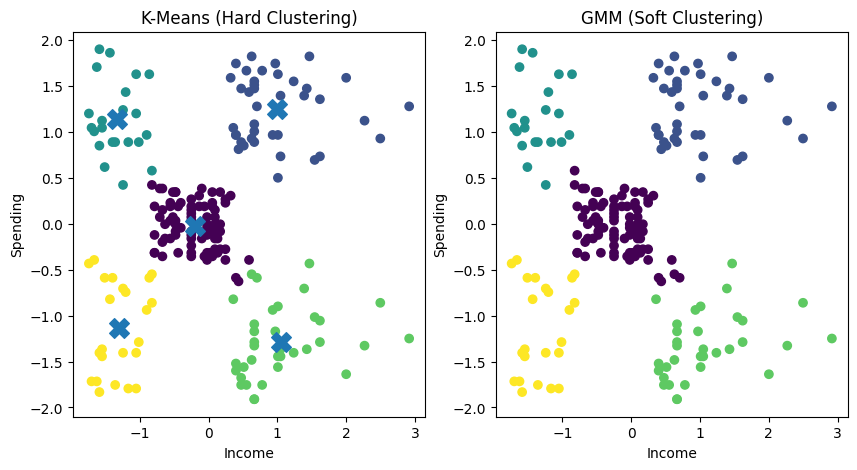

In [3]:
print("Preethi R 24BAD091 \n")

# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.stats import norm

# Load Dataset
df = pd.read_csv('Mall_Customers.csv')

# Select features
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply GMM
gmm = GaussianMixture(n_components=5, random_state=42)
gmm.fit(X_scaled)

labels = gmm.predict(X_scaled)
probs = gmm.predict_proba(X_scaled)

df['GMM_Cluster'] = labels

# Evaluation Metrics
print("Log-Likelihood:", gmm.score(X_scaled))
print("AIC:", gmm.aic(X_scaled))
print("BIC:", gmm.bic(X_scaled))
print("Silhouette Score:", silhouette_score(X_scaled, labels))

# 1. Cluster Probability Distribution (Histogram)
plt.hist(probs.max(axis=1), bins=10)
plt.title('Cluster Probability Distribution')
plt.xlabel('Max Probability')
plt.ylabel('Frequency')
plt.show()

# 2. Scatter Plot (Clusters)
plt.figure(figsize=(8,6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, s=50)
plt.title('GMM Clusters')
plt.xlabel('Annual Income (scaled)')
plt.ylabel('Spending Score (scaled)')
plt.grid(True)
plt.show()

# 3. Income Distribution
x_income = np.linspace(X_scaled[:,0].min(), X_scaled[:,0].max(), 100)

plt.figure()
for i in range(gmm.n_components):
    mean = gmm.means_[i, 0]
    std = np.sqrt(gmm.covariances_[i][0][0])
    y = norm.pdf(x_income, mean, std)
    plt.plot(x_income, y, label=f'Cluster {i}')

plt.title('Income Distribution (GMM)')
plt.xlabel('Annual Income (scaled)')
plt.ylabel('Probability Density')
plt.legend()
plt.show()

# 4. Spending Distribution
x_spend = np.linspace(X_scaled[:,1].min(), X_scaled[:,1].max(), 100)

plt.figure()
for i in range(gmm.n_components):
    mean = gmm.means_[i, 1]
    std = np.sqrt(gmm.covariances_[i][1][1])
    y = norm.pdf(x_spend, mean, std)
    plt.plot(x_spend, y, label=f'Cluster {i}')

plt.title('Spending Score Distribution (GMM)')
plt.xlabel('Spending Score (scaled)')
plt.ylabel('Probability Density')
plt.legend()
plt.show()

# 5. GMM Contour Plot
x = np.linspace(X_scaled[:,0].min(), X_scaled[:,0].max(), 100)
y = np.linspace(X_scaled[:,1].min(), X_scaled[:,1].max(), 100)

X_grid, Y_grid = np.meshgrid(x, y)
XX = np.array([X_grid.ravel(), Y_grid.ravel()]).T

Z = -gmm.score_samples(XX)
Z = Z.reshape(X_grid.shape)

plt.figure()
plt.contour(X_grid, Y_grid, Z)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels)
plt.title('GMM Contour Plot')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.show()

# 6. Comparison Plot (K-Means vs GMM)
kmeans = KMeans(n_clusters=5, random_state=42)
k_labels = kmeans.fit_predict(X_scaled)

fig, ax = plt.subplots(1, 2, figsize=(10,5))

ax[0].scatter(X_scaled[:, 0], X_scaled[:, 1], c=k_labels)
ax[0].scatter(kmeans.cluster_centers_[:,0],
              kmeans.cluster_centers_[:,1],
              marker='X', s=200)
ax[0].set_title('K-Means (Hard Clustering)')
ax[0].set_xlabel('Income')
ax[0].set_ylabel('Spending')

ax[1].scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels)
ax[1].set_title('GMM (Soft Clustering)')
ax[1].set_xlabel('Income')
ax[1].set_ylabel('Spending')

plt.show()